In [63]:
import pandas as pd

df=pd.read_csv(r"C:\Users\DELL\Desktop\House price predication\data\enhanced_house_price_dataset.csv")

print(df.head())
print(df.shape)

   Area  Bedrooms  Bathrooms  Stories  Parking  Age     City      Furnishing  \
0  1260         4          3        2        1   24     Pune  Semi-Furnished   
1  5790         2          1        1        1    7  Kolkata     Unfurnished   
2  5626         5          2        3        0   15  Chennai  Semi-Furnished   
3  5591         1          1        1        1   47    Delhi       Furnished   
4  4172         5          1        1        1   44    Delhi     Unfurnished   

  Main Road Guest Room Basement Water Supply Air Conditioning  \
0       Yes        Yes      Yes         Both               No   
1       Yes        Yes      Yes         Both              Yes   
2        No        Yes      Yes  Corporation              Yes   
3       Yes         No      Yes     Borewell               No   
4        No         No       No     Borewell              Yes   

  Preferred Tenant  Locality Rating    Price  
0          Company                4  1274350  
1         Bachelor                

In [64]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Area              2000 non-null   int64 
 1   Bedrooms          2000 non-null   int64 
 2   Bathrooms         2000 non-null   int64 
 3   Stories           2000 non-null   int64 
 4   Parking           2000 non-null   int64 
 5   Age               2000 non-null   int64 
 6   City              2000 non-null   object
 7   Furnishing        2000 non-null   object
 8   Main Road         2000 non-null   object
 9   Guest Room        2000 non-null   object
 10  Basement          2000 non-null   object
 11  Water Supply      2000 non-null   object
 12  Air Conditioning  2000 non-null   object
 13  Preferred Tenant  2000 non-null   object
 14  Locality Rating   2000 non-null   int64 
 15  Price             2000 non-null   int64 
dtypes: int64(8), object(8)
memory usage: 250.1+ KB
None
        

In [65]:
# check null and duplicate value
print(df.notnull().sum())
print(df.duplicated().sum())

Area                2000
Bedrooms            2000
Bathrooms           2000
Stories             2000
Parking             2000
Age                 2000
City                2000
Furnishing          2000
Main Road           2000
Guest Room          2000
Basement            2000
Water Supply        2000
Air Conditioning    2000
Preferred Tenant    2000
Locality Rating     2000
Price               2000
dtype: int64
0


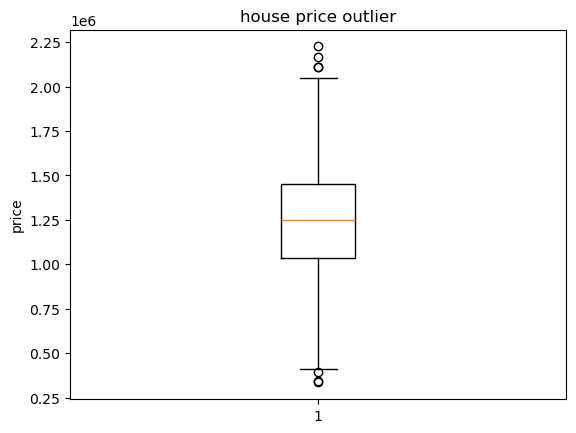

In [66]:
# find outlier
import matplotlib.pyplot as plt
plt.boxplot(df["Price"])
plt.ylabel("price")
plt.title("house price outlier")
plt.show()

In [67]:
# new fature
df["Price_per_sqft"]=df["Price"]/df["Area"]

                     Area  Bedrooms  Bathrooms   Stories   Parking       Age  \
Area             1.000000  0.020302   0.031540 -0.011335 -0.014196  0.004047   
Bedrooms         0.020302  1.000000   0.008483 -0.013706 -0.028421  0.022923   
Bathrooms        0.031540  0.008483   1.000000 -0.051423  0.016337 -0.014590   
Stories         -0.011335 -0.013706  -0.051423  1.000000 -0.018388 -0.014798   
Parking         -0.014196 -0.028421   0.016337 -0.018388  1.000000 -0.004367   
Age              0.004047  0.022923  -0.014590 -0.014798 -0.004367  1.000000   
Locality Rating -0.006288  0.045595  -0.023899  0.017089 -0.053704  0.022192   
Price            0.339137  0.600588   0.267506  0.205615  0.159216 -0.056614   
Price_per_sqft  -0.721320  0.176056   0.059102  0.060031  0.071523 -0.024684   

                 Locality Rating     Price  Price_per_sqft  
Area                   -0.006288  0.339137       -0.721320  
Bedrooms                0.045595  0.600588        0.176056  
Bathrooms       

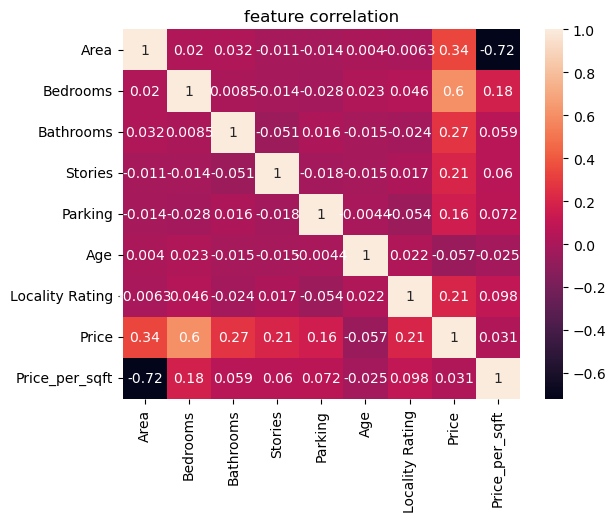

In [68]:
# relation between numerical value
print(df.corr(numeric_only=True))

import seaborn as sns
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.title("feature correlation")
plt.show()

In [69]:
# axis=0 → rows,axis=1 → columns
X=df.drop(["Price","Price_per_sqft"],axis=1)
y=df["Price"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2000, 15)
y shape: (2000,)


In [70]:
# identify numerical and categorical column
numerical_c=X.select_dtypes(include=["int64","float64"]).columns
categorical_c=X.select_dtypes(include=["object"]).columns

print(numerical_c)
print(categorical_c)

Index(['Area', 'Bedrooms', 'Bathrooms', 'Stories', 'Parking', 'Age',
       'Locality Rating'],
      dtype='object')
Index(['City', 'Furnishing', 'Main Road', 'Guest Room', 'Basement',
       'Water Supply', 'Air Conditioning', 'Preferred Tenant'],
      dtype='object')


In [71]:
# ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor=ColumnTransformer(transformers=[("cat",
                                        OneHotEncoder(handle_unknown="ignore"),
                                        categorical_c),
                                        ("num",
                                         StandardScaler(),
                                         numerical_c
                                         )],
                                        remainder="passthrough"
                             )


In [72]:
# Create an ML Pipeline for 3 algo to cheack what is give best predication
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor

model_lin=Pipeline([
    ("prepocessor",preprocessor),
    ("regression",LinearRegression())
])

model_random=Pipeline([
    ("preprocessor",preprocessor),
    ("regression",RandomForestRegressor(n_estimators=100,random_state=42))
])

model_gb=Pipeline([
    ("preprocessor",preprocessor),
    ("regression",GradientBoostingRegressor(random_state=42))
])

In [73]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [74]:
# Train (fit)
model_lin.fit(X_train, y_train)
model_random.fit(X_train, y_train)
model_gb.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['City', 'Furnishing', 'Main Road', 'Guest Room', 'Basement',
       'Water Supply', 'Air Conditioning', 'Preferred Tenant'],
      dtype='object')),
                                                 ('num', StandardScaler(),
                                                  Index(['Area', 'Bedrooms', 'Bathrooms', 'Stories', 'Parking', 'Age',
       'Locality Rating'],
      dtype='object'))])),
                ('regression', GradientBoostingRegressor(random_state=42))])

In [75]:
pre_lin=model_lin.predict(X_test)
pre_random=model_random.predict(X_test)
pre_gb=model_gb.predict(X_test)

In [77]:
# comparision table
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
result=pd.DataFrame({
    "model":[ "Linear Regression",
        "Random Forest Regressor",
        "Gradient Boosting Regressor"],
    "MAE":[mean_absolute_error(y_test,pre_lin),
           mean_absolute_error(y_test,pre_random),
           mean_absolute_error(y_test,pre_gb)],
    "MSE":[mean_squared_error(y_test,pre_lin),
           mean_squared_error(y_test,pre_random),
           mean_squared_error(y_test,pre_gb)],
    "r2":[r2_score(y_test,pre_lin),
           r2_score(y_test,pre_random),
           r2_score(y_test,pre_gb)]
})

print(result)

                         model            MAE           MSE        r2
0            Linear Regression  111763.710469  2.013303e+10  0.777884
1      Random Forest Regressor  138850.615300  2.955509e+10  0.673936
2  Gradient Boosting Regressor  121036.359972  2.282698e+10  0.748163


In [78]:
from sklearn.model_selection import cross_val_score

score=cross_val_score(model_random,X,y,cv=5,scoring="r2")

print("r2 score",score)
print("avg of r2",score.mean())

r2 score [0.65425649 0.60962289 0.64391206 0.69600241 0.64873453]
avg of r2 0.6505056739512554


In [85]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "regression__n_estimators": [50, 100],
    "regression__max_depth": [10, 20]
}

grid_search = GridSearchCV(
    model_random,
    param_grid,
    cv=5,
    scoring="r2"
)

grid_search.fit(X_train, y_train)

print(grid_search.best_params_)

{'regression__max_depth': 10, 'regression__n_estimators': 100}


In [80]:
new_house=pd.DataFrame({
    "Area":[1500],
    "Bedrooms":[3],
    "Bathrooms":[2],
    "Stories":[2],
    "Parking":[1],
    "Age":[5],
    "City":["Rajkot"],
    "Furnishing":["Furnished"],
    "Main Road":["Yes"],
    "Guest Room":["No"],
    "Basement":["No"],
    "Water Supply":["Yes"],
    "Air Conditioning":["Yes"],
    "Preferred Tenant":["Family"],
    "Locality Rating":[8]
    })

predictd_price=grid_search.best_estimator_.predict(new_house)
print("pridicted house price:",predictd_price[0])

pridicted house price: 1233306.8075054237


In [81]:
print(X_train.columns)
print(new_house.columns)

Index(['Area', 'Bedrooms', 'Bathrooms', 'Stories', 'Parking', 'Age', 'City',
       'Furnishing', 'Main Road', 'Guest Room', 'Basement', 'Water Supply',
       'Air Conditioning', 'Preferred Tenant', 'Locality Rating'],
      dtype='object')
Index(['Area', 'Bedrooms', 'Bathrooms', 'Stories', 'Parking', 'Age', 'City',
       'Furnishing', 'Main Road', 'Guest Room', 'Basement', 'Water Supply',
       'Air Conditioning', 'Preferred Tenant', 'Locality Rating'],
      dtype='object')


In [86]:
import joblib
from pathlib import Path

model_path = Path("../models/house_price_model.pkl")


joblib.dump(grid_search.best_estimator_, model_path)
print("Model saved successfully!")
print(model_path)

Model saved successfully!
..\models\house_price_model.pkl


In [87]:
model = joblib.load("../models/house_price_model.pkl")

print("Model loaded successfully!")

Model loaded successfully!


In [88]:
prediction = model.predict(new_house)
print("Predicted House Price:", prediction[0])

Predicted House Price: 1233306.8075054237
